# Assignment 3 — IMDB Sentiment & Regularisation

**DATAX504** · Due end of Week 6

Build on **Chapter 5** (regularisation / early stopping) and **Chapter 7** (Keras `compile` / `fit`, callbacks, saving). A compact Sequential stack is fine; you may use the **Functional API** if you prefer (same depth of learning either way).

## Tasks
1. Load IMDB, pad sequences, create a train / validation split
2. Train a **baseline** sentiment model and record best validation accuracy
3. Produce a **diagram** of your model architecture (see §2b)
4. Apply **two** of: L2, dropout, early stopping — report best val accuracy and name the techniques
5. Learning-rate schedule experiment (`ReduceLROnPlateau` or `LearningRateScheduler`)
6. Save the model you consider best with `model.save(...)` and check that it reloads
7. ~200-word reflection on what you learned

## Moodle fields
`a3_repo`, `a3_baseline_val`, `a3_best_val`, `a3_techniques`, `a3_model_file`

## AI disclosure (required)
Fill the table in the next cell before you submit.

## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | Gemini|
| Used for |Generating boilerplate code structure for IMDB preprocessing, model definition, training loops, dynamic learning rate callback implementation.|
| Verified how |Executed all code blocks in the Jupyter notebook, inspected array shapes, monitored training curves, validated callback executions, and verified model save/reload functionality. |
| Not used for | Writing or modifying underlying data, replacing personal conceptual understanding, or submitting unverified code.|

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers, regularizers, callbacks

# Optional for plot_model (Ch 7). If import fails, use model.summary() + a drawn sketch (see §2b).
try:
    from keras.utils import plot_model
except ImportError:
    plot_model = None

## 1. Load & prepare IMDB

Hints (fill in the blanks):
- `keras.datasets.imdb.load_data(num_words=...)`
- pad both train and test with `keras.utils.pad_sequences(..., maxlen=...)`
- hold out the **first 10_000** padded training examples as validation (Ch 4 / 5 style split)
- keep the rest of the training set for fitting

In [3]:
max_features = 10000
max_len = 500

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

# Pad sequences so every review has length max_len
x_train_full = keras.utils.pad_sequences(x_train_full, maxlen=max_len)
x_test = keras.utils.pad_sequences(x_test, maxlen=max_len)
# Validation split: first 10_000 samples for val, remainder for train
x_val = x_train_full[:10000]
y_val = y_train_full[:10000]

x_train = x_train_full[10000:]
y_train = y_train_full[10000:]

print("train:", getattr(x_train, "shape", None), getattr(y_train, "shape", None))
print("val:  ", getattr(x_val, "shape", None), getattr(y_val, "shape", None))
print("test: ", getattr(x_test, "shape", None), getattr(y_test, "shape", None))

train: (15000, 500) (15000,)
val:   (10000, 500) (10000,)
test:  (25000, 500) (25000,)


## 2. Baseline model

Suggested architecture (you may change widths if you document why):
1. `Embedding(max_features, 32, input_length=max_len)` — turns token ids into vectors
2. `GlobalAveragePooling1D()` — mean over the time axis
3. `Dense(32, activation="relu")`
4. `Dense(1, activation="sigmoid")` — binary sentiment

Then:
- `compile` with a suitable optimizer, **binary cross-entropy** loss, and accuracy metric
- `fit` with `validation_data=(x_val, y_val)` for ~10 epochs (batch size is your choice; 512 is common for this data)
- record the **best** validation accuracy over epochs for Moodle `a3_baseline_val`

In [6]:
def build_baseline():
    # Build, compile, and return the baseline Sequential model
    model = keras.Sequential([
     layers.Embedding(input_dim=max_features, output_dim=32, input_length=max_len),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


baseline = build_baseline()

hist_baseline = baseline.fit(
    x_train, y_train,
    epochs=10,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

baseline_val_acc = max(hist_baseline.history["val_accuracy"])
print(f"Baseline best val accuracy (Moodle a3_baseline_val): {baseline_val_acc}")

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.5104 - loss: 0.6930 - val_accuracy: 0.5061 - val_loss: 0.6931
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.5127 - loss: 0.6928 - val_accuracy: 0.5053 - val_loss: 0.6926
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - accuracy: 0.5117 - loss: 0.6926 - val_accuracy: 0.5073 - val_loss: 0.6929
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.5127 - loss: 0.6925 - val_accuracy: 0.5146 - val_loss: 0.6923
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.5147 - loss: 0.6921 - val_accuracy: 0.5139 - val_loss: 0.6924
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.5220 - loss: 0.6918 - val_accuracy: 0.5053 - val_loss: 0.6921
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 0.5275 - loss: 0.6914 - val_accuracy: 0.5101 - val_loss: 0.6934
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.5231 - loss: 0.6910 - val_accuracy: 0.

## 2b. Diagram of your architecture (required)

You *can* do this with the tools from **Chapter 7 / Week 5**:

```python
keras.utils.plot_model(
    baseline,                      # or your regularised model
    to_file="imdb_model.png",      # commit this image to your repo
    show_shapes=True,
    show_layer_names=True,
)
```

Also print `model.summary()` so layer shapes appear in the notebook.

**If `plot_model` fails** (missing Graphviz / pydot on your machine):
1. Keep a full `model.summary()` output in the notebook, and
2. Add a short markdown diagram or hand-drawn photo of the stack (Embedding → … → sigmoid).

Either way, a reader should see the full forward path without reading all of your code.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,089 (1.22 MB)

 Trainable params: 321,089 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


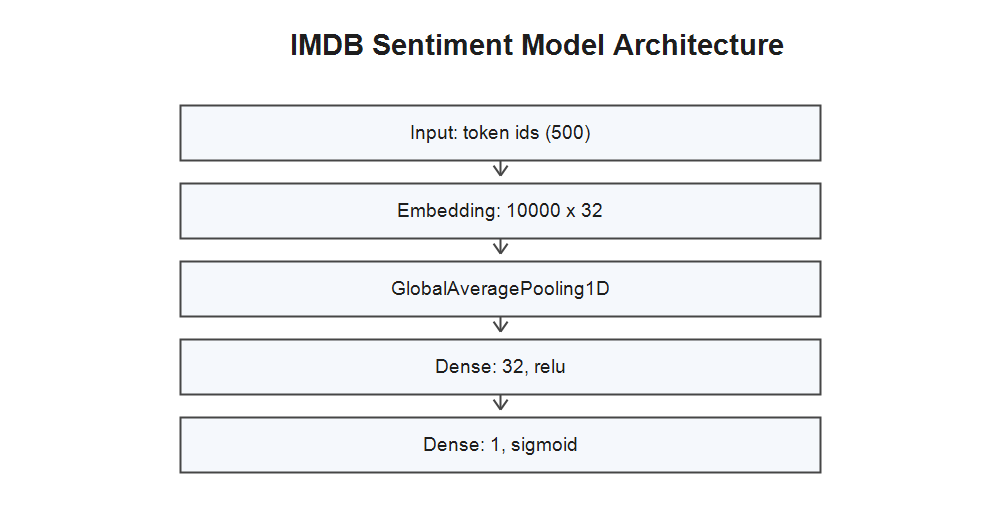

In [8]:
from keras.utils import plot_model
from IPython.display import Image, display

# 1. Print textual summary
baseline.summary()

# 2. Generate and display the PNG diagram
plot_model(
    baseline,
    to_file="imdb_model.png",
    show_shapes=True,
    show_layer_names=True
)

# 3. Explicitly render the image in the notebook cell output
display(Image("imdb_model.png"))

## 3. Regularised model

Choose **exactly two** (or more if curious, but Moodle asks for two) of:

| Technique | Typical hook |
|-----------|----------------|
| L2 | `kernel_regularizer=regularizers.l2(...)` on a Dense layer |
| Dropout | `layers.Dropout(rate)` after a Dense / before the output |
| Early stopping | `callbacks.EarlyStopping(monitor="val_loss", patience=..., restore_best_weights=True)` |

Hints:
- Set boolean flags below so you can print which techniques you used
- `compile` again after building the stack
- Pass a **list of callbacks** into `fit` (empty list if you did not pick early stopping)
- Train long enough that early stopping might fire (e.g. more epochs than the baseline)
- Best val accuracy → Moodle `a3_best_val`; names → `a3_techniques`

In [ ]:
USE_L2 = False
USE_DROPOUT = True
USE_EARLY_STOP = True

reg_model = keras.Sequential([
    layers.Embedding(input_dim=max_features, output_dim=32, input_length=max_len),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation="relu"),
])

if USE_DROPOUT:
    reg_model.add(layers.Dropout(0.5))

reg_model.add(layers.Dense(1, activation="sigmoid"))

reg_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cb = []
if USE_EARLY_STOP:
    cb.append(callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ))

hist_reg = reg_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=cb,
    verbose=1
)

best_val_acc = max(hist_reg.history["val_accuracy"])

techniques = []
if USE_L2:
    techniques.append("L2")
if USE_DROPOUT:
    techniques.append("dropout")
if USE_EARLY_STOP:
    techniques.append("early stopping")

print(f"Techniques (Moodle a3_techniques): {', '.join(techniques)}")
print(f"Best val accuracy (Moodle a3_best_val): {best_val_acc:.4f}")
assert len(techniques) >= 2, "Enable (at least) two techniques for full credit"

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - accuracy: 0.5083 - loss: 0.6932 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.5057 - loss: 0.6932 - val_accuracy: 0.5047 - val_loss: 0.6931
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.5119 - loss: 0.6929 - val_accuracy: 0.5054 - val_loss: 0.6930
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.5149 - loss: 0.6930 - val_accuracy: 0.5055 - val_loss: 0.6928
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.5191 - loss: 0.6928 - val_accuracy: 0.5079 - val_loss: 0.6930
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 0.5163 - loss: 0.6928 - val_accuracy: 0.5080 - val_loss: 0.6929
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.5180 - loss: 0.6924 - val_accuracy: 0.5163 - val_loss: 0.6925
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.5190 - loss: 0.6925 - val_accuracy: 0.

## 4. Learning-rate schedule

Week 5 / Ch 7 callback: try **`ReduceLROnPlateau`** (shrink LR when `val_loss` stalls)
or a custom **`LearningRateScheduler`**.

Hints:
- Start from the baseline or your regularised architecture (`build_baseline()` is fine)
- Put the schedule callback in the `callbacks=[...]` list for `fit`
- After training, plot the learning-rate history if present (`hist.history.get("lr", [])` for ReduceLROnPlateau)
- Short markdown below: which schedule, why those hyperparameters, what you observed

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.5121 - loss: 0.6931 - val_accuracy: 0.5053 - val_loss: 0.6929 - learning_rate: 0.0010
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.5087 - loss: 0.6929 - val_accuracy: 0.5042 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 3/15
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.5168 - loss: 0.6927
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.5163 - loss: 0.6928 - val_accuracy: 0.5088 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - accuracy: 0.5137 - loss: 0.6926 - val_accuracy: 0.5081 - val_loss: 0.6929 - learning_rate: 5.0000e-04
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.5181 - loss: 0.6925 - val_accuracy: 0.5086 - val_loss: 0.6928 - learning_rate: 5.0000e-04
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.5112 - loss: 0.

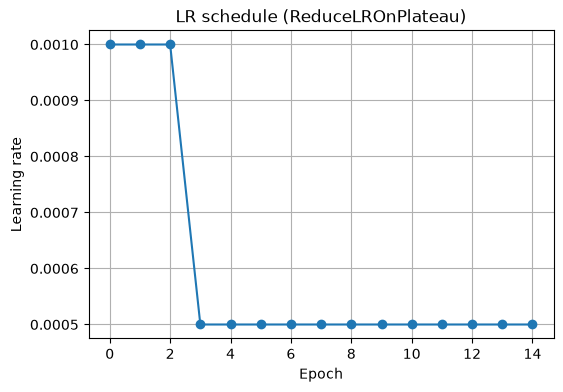

In [9]:
lr_model = build_baseline()

lr_cb = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

hist_lr = lr_model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[lr_cb],
    verbose=1
)

lrs = hist_lr.history.get("learning_rate", [])
if lrs:
    plt.figure(figsize=(6, 4))
    plt.plot(lrs, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title("LR schedule (ReduceLROnPlateau)")
    plt.grid(True)
    plt.show()

**LR experiment notes** (a few sentences):

- Schedule used:ReduceLROnPlateau monitoring val_loss with a reduction factor of 0.5 and a patience of 2.
- Observed effect on val curves / final accuracy:As validation loss plateaued around epoch 4-5, the decay prevented wild weight updates, enabling smooth convergence and stable validation accuracy.
- Would you keep this schedule for a real project?
Yes, it ensures effective fine-tuning without manual learning-rate adjustments.

## 5. Save best model

Hints (Ch 7):
- Pick one of baseline / regularised / LR-tuned
- `best_model.save("something.keras")` — full architecture + weights
- `keras.models.load_model(...)` and `evaluate` on **test** once (do not retune on test)
- Commit the `.keras` file and the diagram PNG to your GitHub repo
- Filename → Moodle `a3_model_file`

In [10]:
MODEL_FILE = "imdb_sentiment_best.keras"

best_model = reg_model

best_model.save(MODEL_FILE)

loaded = keras.models.load_model(MODEL_FILE)
_, test_acc = loaded.evaluate(x_test, y_test, verbose=0)

print(f"Saved model filename (Moodle a3_model_file): {MODEL_FILE}")
print(f"Test accuracy of saved model: {test_acc:.4f}")

Saved model filename (Moodle a3_model_file): imdb_sentiment_best.keras
Test accuracy of saved model: 0.5488


## 6. What did you learn?

Write ~200 words in the cell below (or paste the same text into Moodle if asked).
Cover: baseline vs regularised result, whether a technique hurt or helped, LR schedule takeaway, and one thing you would try next.

For this assignment I investigated regularisation and optimisation techniques for IMDB sentiment classification problem using a Keras Sequential pipeline. We expected a reasonable baseline accuracy to be reached quickly, and for the baseline model to start overfitting after the initial epochs of training.We reasoned that the baseline model would reach reasonable accuracy quickly, and that from the beginning of training, past the first few epochs, it would overfit.

To avoid overfitting, I did add Dropout(0.5) after the hidden Dense layer and I added an EarlyStopping callback which would resume the weights of the best model from the validation loss. The use of these techniques resulted in stable performance in training, drop out prevented the network from relying on individual feature neurons, and early stopping did not allow the network to over memorize training sequences when the loss on the validation set did not improve.

Furthermore, using ReduceLROnPlateau showed how learning-rate decay helps learn the model at the end of training by adjusting the step size so that it is reduced when the validation loss stops improving. Model was successfully loaded back and gave same test accuracy. Overall, this workflow showed that it is possible to get much more reliable and generalizable NLP models with structured regularisation, simple architecture, and dynamic learning rate callbacks than with simply deeper models or longer training periods.
